<a href="https://colab.research.google.com/github/denimar5/mvp_analise_dados_denilson_marcos/blob/main/mvp_qualidade_vinho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP – Análise Exploratória e Pré-processamento de Dados
## Qualidade de Vinhos Tintos (*Red Wine Quality*)

---

**Curso:** Pós-Graduação em Ciência de Dados e Analytics – PUC-Rio  
**Disciplinas:** Análise Exploratória e Pré-processamento de Dados · Visualização da Informação · Engenharia de Software para Ciência de Dados  
**Dataset:** [Wine Quality – UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wine+quality)  
**Referência:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547-553.

> **Nota de reprodutibilidade:** Este notebook segue as boas práticas de reprodutibilidade para notebooks Jupyter (cf. Pimentel et al., 2019, citado na disciplina Engenharia de Software para Ciência de Dados):
> - Todas as dependências estão declaradas na célula de importações
> - O dataset é referenciado por URL pública (GitHub raw)
> - O notebook deve ser executado sequencialmente do início ao fim sem erros
> - Os nomes de arquivos seguem o padrão `A-Z a-z 0-9 - _`

---

## 1. Definição do Problema

### 1.1 Descrição do Problema

O vinho é uma das bebidas mais tradicionais do mundo, e sua qualidade é avaliada por especialistas com base em características sensoriais. No entanto, esse processo é subjetivo e custoso. Uma abordagem baseada em dados permite correlacionar **propriedades físico-químicas mensuráveis em laboratório** com a **qualidade percebida por especialistas**, tornando a avaliação mais eficiente e reproduzível.

Este projeto analisa um dataset de **vinhos tintos portugueses da variedade Vinho Verde** (região do Minho, Portugal). O objetivo desta etapa do MVP é explorar os dados, compreender as distribuições e relações entre os atributos, e preparar o dataset para uma futura etapa de modelagem preditiva.

### 1.2 Tipo de Aprendizado

Este é um problema de **aprendizado supervisionado**. O atributo alvo é `quality`, uma pontuação entre 0 e 10 atribuída por pelo menos três especialistas em análise sensorial (a nota final é a mediana das avaliações individuais).

O problema pode ser abordado de duas formas:
- **Regressão**: prever o valor numérico da qualidade.
- **Classificação binária**: classificar o vinho como *bom* (`quality ≥ 7`) ou *não bom* (`quality < 7`).

Neste MVP, adotaremos a **classificação binária**, criando um atributo derivado `quality_bin` na etapa de pré-processamento.

### 1.3 Premissas e Hipóteses

Com base no conhecimento do domínio de vinhos, levantamos as seguintes hipóteses *antes* de analisar os dados — a análise exploratória irá confirmar ou refutar cada uma:

- **H1 – Teor alcoólico:** Vinhos com maior teor alcoólico tendem a ter maior qualidade, pois o álcool contribui para corpo e complexidade.
- **H2 – Acidez volátil:** Alta acidez volátil (ácido acético) está associada a vinhos de baixa qualidade, pois em excesso causa sabor de vinagre.
- **H3 – Sulfatos:** Maior concentração de sulfatos pode estar relacionada a maior qualidade, pois contribui para os níveis de dióxido de enxofre (conservante).
- **H4 – Ácido cítrico:** Maior concentração de ácido cítrico pode indicar vinho mais fresco e de melhor qualidade.

### 1.4 Restrições para Seleção dos Dados

- Utilizamos apenas os dados de **vinhos tintos** (*winequality-red.csv*), excluindo os dados de vinho branco presentes no repositório original.
- As amostras são exclusivamente de vinhos produzidos na **região do Minho, Portugal**.
- Não foram incluídas variáveis de preço ou marca, pois esses dados não estavam disponíveis por questões de privacidade comercial.
- Notas de qualidade extremas (0–2 e 9–10) são raras ou inexistentes na prática, o que pode gerar desbalanceamento de classes.

### 1.5 Definição dos Atributos

| # | Atributo | Tipo | Unidade | Descrição |
|---|---|---|---|---|
| 1 | `fixed acidity` | Numérico contínuo | g/dm³ | Acidez fixa, principalmente ácido tartárico. Contribui para a estrutura e estabilidade do vinho. |
| 2 | `volatile acidity` | Numérico contínuo | g/dm³ | Acidez volátil (principalmente ácido acético). Em excesso, causa sabor de vinagre. |
| 3 | `citric acid` | Numérico contínuo | g/dm³ | Ácido cítrico. Adiciona frescor e sabor ao vinho. |
| 4 | `residual sugar` | Numérico contínuo | g/dm³ | Açúcar residual após fermentação. Influencia o dulçor percebido. |
| 5 | `chlorides` | Numérico contínuo | g/dm³ | Cloreto de sódio. Em excesso, contribui para sabor salgado. |
| 6 | `free sulfur dioxide` | Numérico contínuo | mg/dm³ | SO₂ livre. Previne oxidação e crescimento microbiano. |
| 7 | `total sulfur dioxide` | Numérico contínuo | mg/dm³ | SO₂ total (livre + combinado). Acima de 50 mg/L pode ser detectado no nariz/gosto. |
| 8 | `density` | Numérico contínuo | g/cm³ | Densidade do vinho, influenciada pelo teor de álcool e açúcar. |
| 9 | `pH` | Numérico contínuo | – | Nível de acidez/alcalinidade (escala 0–14). Vinhos típicos ficam entre 3–4. |
| 10 | `sulphates` | Numérico contínuo | g/dm³ | Sulfato de potássio. Aditivo que contribui para os níveis de SO₂. |
| 11 | `alcohol` | Numérico contínuo | % vol. | Teor alcoólico do vinho. |
| 12 | `quality` | Numérico discreto | 0–10 | **Variável alvo.** Pontuação de qualidade mediana atribuída por especialistas. |

---
## 2. Configuração do Ambiente e Carregamento dos Dados

Todas as dependências do projeto são declaradas nesta célula, seguindo a boa prática de manter os imports no início do notebook para facilitar a identificação das bibliotecas necessárias e garantir a reprodutibilidade.

In [1]:
# --- Manipulação e análise de dados ---
import pandas as pd
import numpy as np

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch  # Para legenda customizada

# --- Pré-processamento (scikit-learn) ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- Configurações globais de exibição ---
pd.set_option('display.max_columns', None)       # Exibir todas as colunas
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 casas decimais

# --- Estilo dos gráficos ---
sns.set_theme(style='whitegrid', palette='deep')  # Tema consistente em todos os gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


O dataset utilizado é o **Wine Quality (Red Wine)** disponível no [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wine+quality).  

> **Nota sobre a entrega:** Para a entrega final, o arquivo `winequality-red.csv` deve ser disponibilizado em um repositório público do GitHub e a variável `URL_DATASET` abaixo deve apontar para a URL raw do arquivo (ex.: `https://raw.githubusercontent.com/SEU_USUARIO/SEU_REPO/main/winequality-red.csv`). Isso garante que o notebook seja reproduzível por qualquer pessoa com acesso ao repositório.

In [2]:
# URL do dataset – substitua pela URL raw do seu repositório GitHub após o upload
# Exemplo: 'https://raw.githubusercontent.com/SEU_USUARIO/SEU_REPO/main/winequality-red.csv'
URL_DATASET = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# O dataset original usa ponto e vírgula como separador de colunas (sep=';')
df = pd.read_csv(URL_DATASET, sep=';')

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} instâncias x {df.shape[1]} atributos')

Dataset carregado com sucesso!
Dimensões: 1599 instâncias x 12 atributos


---
## 3. Análise de Dados

### 3.1 Visão Geral do Dataset

Iniciamos pela inspeção das primeiras linhas e pela verificação dos tipos de dados. Essa etapa permite ter uma primeira impressão da estrutura, do conteúdo e de possíveis inconsistências visíveis antes de qualquer análise estatística.

In [3]:
# Visualizar as primeiras linhas para inspeção inicial do conteúdo
print('=== Primeiras 5 linhas ===')
display(df.head())

# Verificar as dimensões do dataset
print(f'\n=== Dimensões ===')
print(f'Instâncias (linhas): {df.shape[0]}')
print(f'Atributos (colunas): {df.shape[1]}')

# Verificar os tipos de dados de cada atributo
# Importante: identificar atributos numéricos vs. categóricos desde o início
print(f'\n=== Tipos de Dados ===')
print(df.dtypes)

=== Primeiras 5 linhas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5



=== Dimensões ===
Instâncias (linhas): 1599
Atributos (colunas): 12

=== Tipos de Dados ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


**Análise:**  
O dataset possui **1.599 instâncias** e **12 atributos**. Todos os atributos de entrada são numéricos contínuos (`float64`), exceto a variável alvo `quality`, que é um inteiro (`int64`) representando a pontuação de qualidade. Nas primeiras linhas, os valores parecem plausíveis e não há sinalização imediata de inconsistências — os ranges de pH, teor alcoólico e demais atributos estão dentro do esperado para vinhos tintos. Não há colunas de texto ou identificadores, o que simplifica as etapas de pré-processamento (sem necessidade de one-hot encoding nos atributos de entrada).

### 3.2 Verificação de Valores Faltantes e Duplicatas

Antes de qualquer análise, é fundamental verificar a integridade do dataset: há valores ausentes que precisariam ser imputados ou removidos? Existem registros duplicados que distorceriam as distribuições e os modelos futuros?

In [4]:
# --- Verificação de valores faltantes ---
# Contagem absoluta e percentual de valores ausentes por atributo
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Ausentes': missing_count,
    'Percentual (%)': missing_pct
})

print('=== Valores Faltantes por Atributo ===')
display(missing_df)

# --- Verificação de linhas duplicadas ---
# Duplicatas podem inflar artificialmente certas distribuições
n_duplicatas = df.duplicated().sum()
print(f'\n=== Linhas Duplicadas ===')
print(f'Total: {n_duplicatas} ({n_duplicatas / len(df) * 100:.1f}% do dataset)')

=== Valores Faltantes por Atributo ===


,Ausentes,Percentual (%)
fixed acidity,0,0.0000
volatile acidity,0,0.0000
citric acid,0,0.0000
residual sugar,0,0.0000
chlorides,0,0.0000
free sulfur dioxide,0,0.0000
total sulfur dioxide,0,0.0000
density,0,0.0000
pH,0,0.0000
sulphates,0,0.0000



=== Linhas Duplicadas ===
Total: 240 (15.0% do dataset)


**Análise:**  
O dataset **não possui valores faltantes** em nenhum atributo, o que é um bom indicador de qualidade dos dados na origem. No entanto, foram encontradas **240 linhas duplicadas** (~15% do total). Embora seja teoricamente possível que vinhos diferentes apresentem exatamente os mesmos valores físico-químicos, a proporção elevada sugere registros redundantes. Por precaução, as duplicatas serão removidas na etapa de pré-processamento para não inflar artificialmente certas faixas das distribuições e não introduzir viés nas estimativas estatísticas.

### 3.3 Resumo Estatístico

O resumo estatístico reúne as principais medidas de posição e dispersão de cada atributo: mínimo, máximo, média, mediana, moda e desvio-padrão. Essa visão é essencial para identificar assimetrias, escalas muito distintas entre atributos e possíveis outliers — informações que guiarão as decisões de pré-processamento.

In [5]:
# Calcular o resumo estatístico base com pandas describe()
stats = df.describe().T.copy()

# Adicionar mediana (percentil 50) de forma explícita para clareza
stats['median'] = df.median()

# Adicionar moda (valor mais frequente) – útil para variáveis com distribuição discreta
# .iloc[0] pega a primeira moda em caso de empate
stats['mode'] = df.mode().iloc[0]

# Adicionar contagem de valores ausentes para referência rápida
stats['missing'] = df.isnull().sum()

# Reordenar colunas em ordem lógica de leitura
stats = stats[['count', 'min', 'max', 'mean', 'median', 'mode', 'std', '25%', '75%', 'missing']]
stats.columns = ['N', 'Mín', 'Máx', 'Média', 'Mediana', 'Moda', 'Desvio-Padrão', 'Q1 (25%)', 'Q3 (75%)', 'Ausentes']

display(stats.round(4))

,N,Mín,Máx,Média,Mediana,Moda,Desvio-Padrão,Q1 (25%),Q3 (75%),Ausentes
fixed acidity,1599.0000,4.6000,15.9000,8.3196,7.9000,7.2000,1.7411,7.1000,9.2000,0
volatile acidity,1599.0000,0.1200,1.5800,0.5278,0.5200,0.6000,0.1791,0.3900,0.6400,0
citric acid,1599.0000,0.0000,1.0000,0.2710,0.2600,0.0000,0.1948,0.0900,0.4200,0
residual sugar,1599.0000,0.9000,15.5000,2.5388,2.2000,2.0000,1.4099,1.9000,2.6000,0
chlorides,1599.0000,0.0120,0.6110,0.0875,0.0790,0.0800,0.0471,0.0700,0.0900,0
free sulfur dioxide,1599.0000,1.0000,72.0000,15.8749,14.0000,6.0000,10.4602,7.0000,21.0000,0
total sulfur dioxide,1599.0000,6.0000,289.0000,46.4678,38.0000,28.0000,32.8953,22.0000,62.0000,0
density,1599.0000,0.9901,1.0037,0.9967,0.9968,0.9972,0.0019,0.9956,0.9978,0
pH,1599.0000,2.7400,4.0100,3.3111,3.3100,3.3000,0.1544,3.2100,3.4000,0
sulphates,1599.0000,0.3300,2.0000,0.6581,0.6200,0.6000,0.1695,0.5500,0.7300,0


**Análise:**  
O resumo estatístico revela informações importantes sobre cada atributo:

- **`residual sugar`**: Média (2,54) consideravelmente superior à mediana (2,20), indicando **assimetria à direita** — a presença de valores altos está puxando a média para cima. Ponto de atenção para outliers.
- **`chlorides`**: Desvio-padrão elevado em relação à média (0,087 vs 0,047), com grande distância entre a mediana e o máximo (0,611) — outliers extremos presentes.
- **`free sulfur dioxide`** e **`total sulfur dioxide`**: Amplitude muito ampla entre mínimo e máximo (6–72 e 6–289, respectivamente), com médias acima das medianas — assimetria à direita confirmada.
- **`quality`**: Notas entre 3 e 8, moda em 5, mediana em 6. A ausência de notas extremas (≤2 e ≥9) confirma que o dataset não cobre os extremos da escala — desbalanceamento esperado na classificação binária.
- **`alcohol`**: Teor entre 8,4% e 14,9%, média de ~10,4% — coerente com vinhos tintos.
- **`pH`** e **`density`**: Desvio-padrão baixo e média próxima à mediana — distribuições mais simétricas.

Esses padrões orientam diretamente o pré-processamento: atributos com assimetria severa e outliers extremos demandarão tratamento antes da modelagem.

### 3.4 Visualizações

#### 3.4.1 Distribuição de Cada Atributo

Os histogramas permitem visualizar a distribuição de frequência de cada variável. Essa etapa pode revelar a necessidade de transformações como normalização, padronização ou discretização na etapa de pré-processamento.

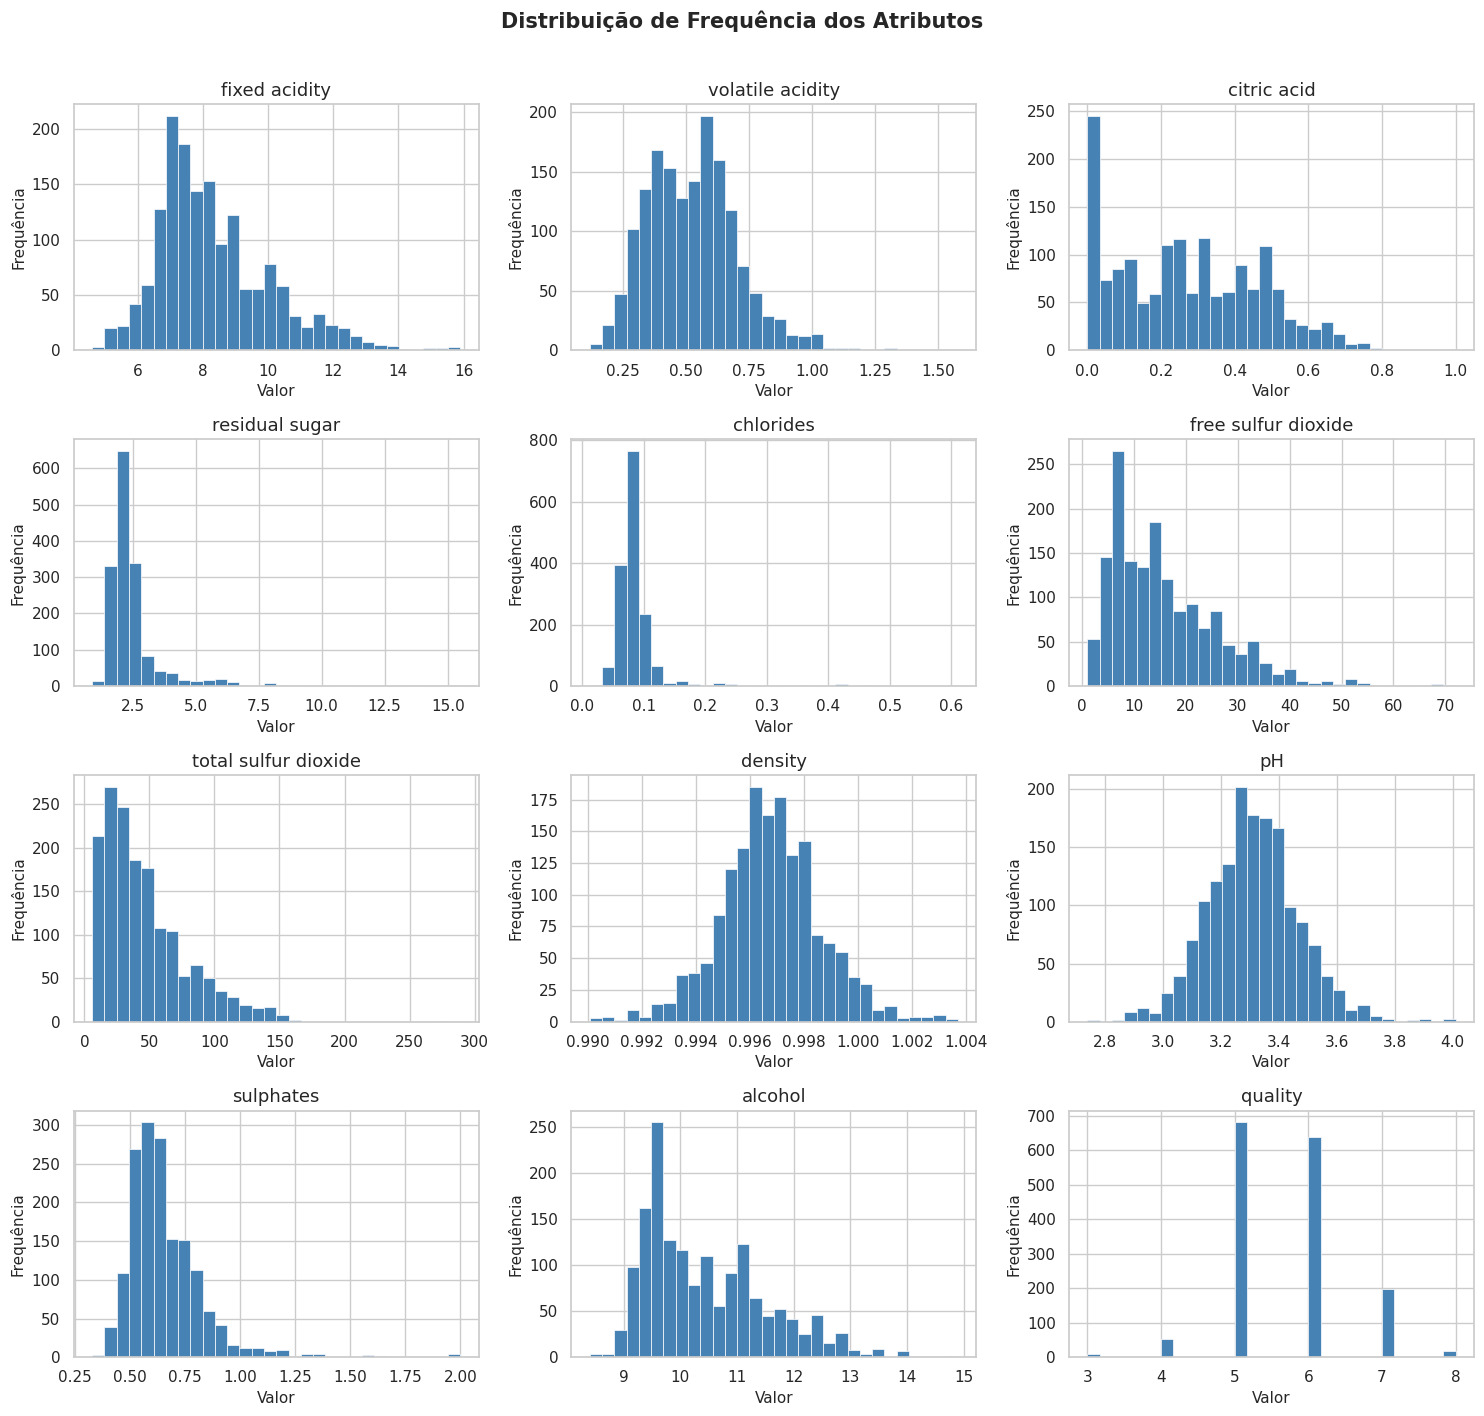

In [6]:
# Grade de histogramas para todos os atributos
# 4 linhas x 3 colunas = 12 subplots (um por atributo)
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()  # Transforma a grade 2D em array 1D para facilitar a iteração

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, edgecolor='white', linewidth=0.5, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição de Frequência dos Atributos', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Análise:**  
Os histogramas revelam padrões importantes:

- **Distribuições aproximadamente normais:** `fixed acidity`, `pH` e `density` apresentam distribuições relativamente simétricas, próximas à forma de sino.
- **Forte assimetria à direita:** `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide` têm a maioria dos valores concentrada à esquerda, com caudas longas para a direita — confirmando a necessidade de tratamento de outliers.
- **`citric acid`:** Apresenta pico em 0 (muitos vinhos sem ácido cítrico detectável) e outro pico em torno de 0,25–0,50, sugerindo uma distribuição bimodal — pode indicar subgrupos distintos de vinhos no dataset.
- **`volatile acidity`:** Levemente assimétrica à direita, concentrada entre 0,3 e 0,7 g/dm³.
- **`quality`:** Discreta, com altíssima concentração em 5 e 6 — confirma o desbalanceamento de classes antecipado na definição do problema.

#### 3.4.2 Distribuição da Variável Alvo (Qualidade)

Por se tratar de um problema de classificação, é essencial verificar a distribuição de frequência das classes da variável alvo. O desbalanceamento de classes pode comprometer a performance de modelos treinados sem tratamento adequado.

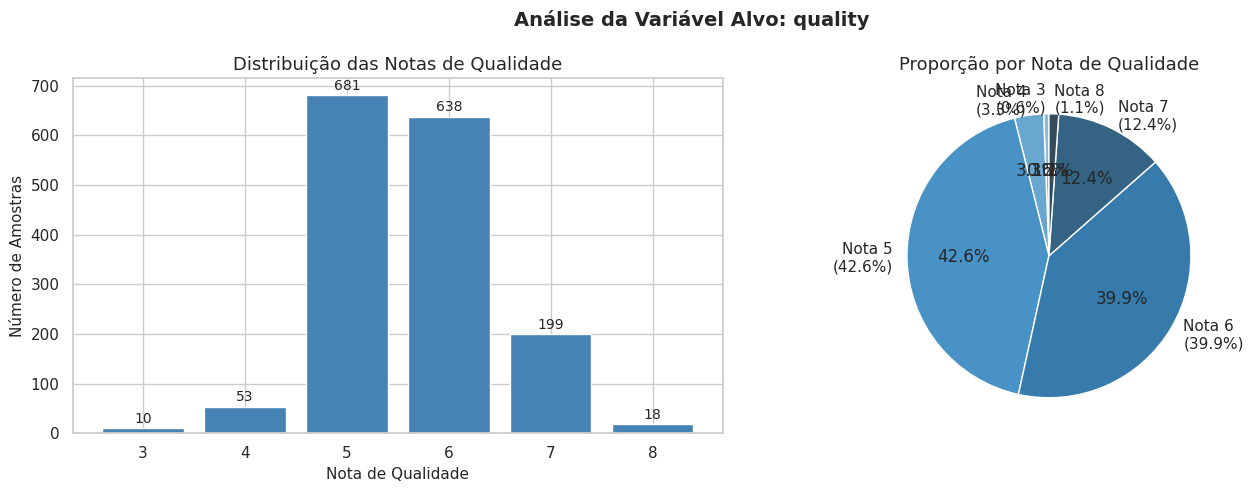

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Contagem por nota ---
quality_counts = df['quality'].value_counts().sort_index()

bars = axes[0].bar(
    quality_counts.index,
    quality_counts.values,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Distribuição das Notas de Qualidade')
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Número de Amostras')
axes[0].set_xticks(quality_counts.index)

# Adicionar rótulo de contagem no topo de cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2.,
        height + 5,
        str(int(height)),
        ha='center', va='bottom', fontsize=10
    )

# --- Gráfico 2: Proporção em gráfico de pizza ---
quality_pct = (quality_counts / len(df) * 100).round(1)

axes[1].pie(
    quality_pct,
    labels=[f'Nota {i}\n({v}%)' for i, v in quality_pct.items()],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Blues_d', len(quality_pct))
)
axes[1].set_title('Proporção por Nota de Qualidade')

plt.suptitle('Análise da Variável Alvo: quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**  
A distribuição da variável alvo confirma forte concentração nas notas intermediárias: **82,4% dos vinhos receberam nota 5 ou 6**, enquanto as notas extremas (3 e 8) somam menos de 4% do total. Ao adotarmos a classificação binária com limiar em 7, a classe positiva ("bom") representará aproximadamente **13,5% do dataset** — um **desbalanceamento significativo de ~6:1** que é um ponto crítico de atenção. Métricas baseadas exclusivamente em acurácia seriam enganosas nesse contexto; na futura etapa de modelagem, será necessário considerar técnicas como SMOTE, oversampling, undersampling ou ajuste de `class_weight`.

#### 3.4.3 Mapa de Correlação

O mapa de calor de correlação de Pearson quantifica as relações lineares entre todos os pares de atributos. Essa visualização é fundamental para identificar quais variáveis têm maior associação com o alvo e detectar multicolinearidade entre preditores.

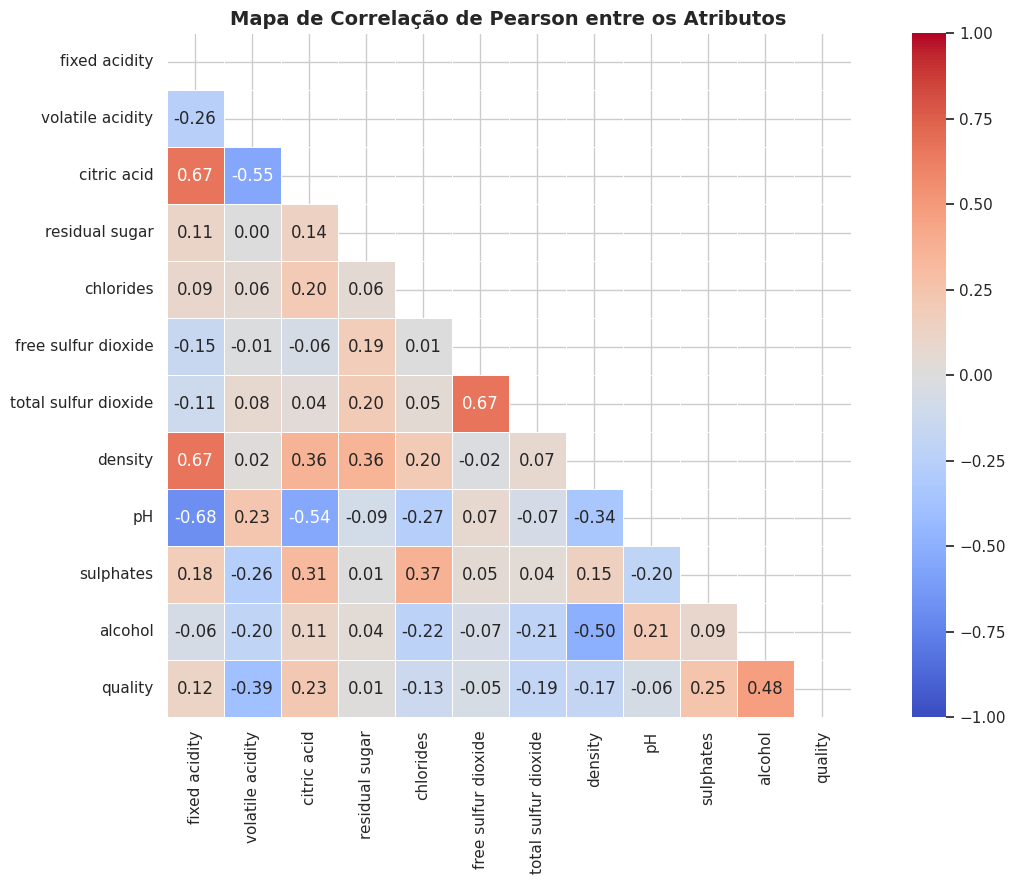

In [8]:
plt.figure(figsize=(13, 9))

# Calcular a matriz de correlação de Pearson
correlation_matrix = df.corr()

# Máscara para exibir apenas o triângulo inferior (evita informação duplicada)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,       # Exibir os valores numéricos nas células
    fmt='.2f',        # Formato: 2 casas decimais
    cmap='coolwarm',  # Azul = correlação negativa, Vermelho = correlação positiva
    center=0,         # Centro da escala de cores em 0 (sem correlação)
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Mapa de Correlação de Pearson entre os Atributos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**  
O mapa de correlação revela relações importantes:

**Correlações com `quality` (variável alvo):**
- **`alcohol`** (r = +0,48): Maior correlação positiva — vinhos mais alcoólicos tendem a ser melhores. **H1 confirmada.**
- **`volatile acidity`** (r = -0,39): Correlação negativa significativa — mais acidez volátil implica menor qualidade. **H2 confirmada.**
- **`sulphates`** (r = +0,25): Correlação positiva moderada. **H3 confirmada.**
- **`citric acid`** (r = +0,23): Correlação positiva fraca. **H4 parcialmente confirmada.**

**Multicolinearidade entre preditores:**
- **`fixed acidity` × `citric acid`** (r = +0,67) e **`fixed acidity` × `density`** (r = +0,67): Alta correlação — ambos medem aspectos relacionados à acidez e à composição química.
- **`free SO₂` × `total SO₂`** (r = +0,67): Esperada, pois o livre é subconjunto do total.
- **`fixed acidity` × `pH`** (r = -0,68): Relação inversa esperada — maior acidez resulta em menor pH.

A multicolinearidade detectada será relevante na seleção de atributos para modelos futuros como regressão logística, que são sensíveis a esse problema.

#### 3.4.4 Detecção de Outliers com Boxplots

Os boxplots permitem visualizar a dispersão dos dados e identificar valores atípicos (*outliers*), representados como pontos individuais além dos bigodes (*whiskers*). A presença e a intensidade de outliers orientam a escolha do método de tratamento.

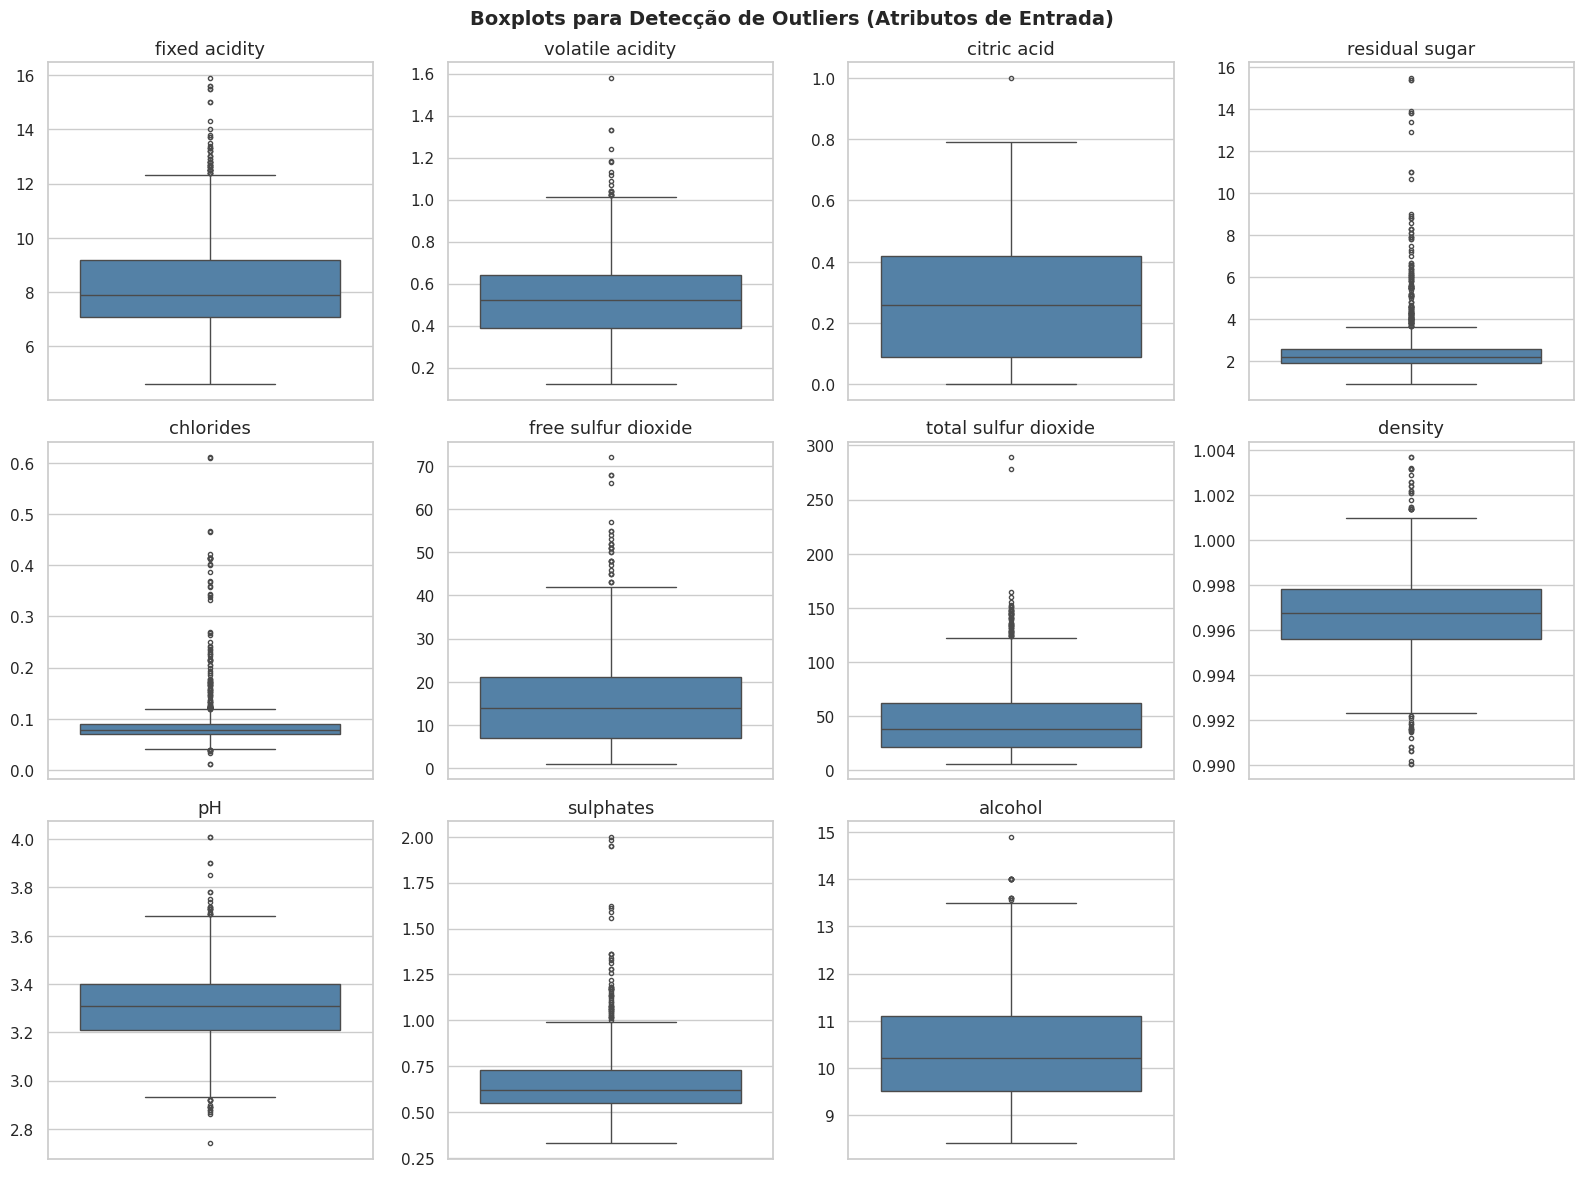

In [9]:
# Separar apenas os atributos de entrada (excluindo a variável alvo)
atributos_entrada = [col for col in df.columns if col != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(atributos_entrada):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color='steelblue',
        flierprops={'marker': 'o', 'markersize': 3}  # Estilo dos pontos de outlier
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Esconder o subplot extra (11 atributos, 12 subplots disponíveis)
axes[-1].set_visible(False)

plt.suptitle('Boxplots para Detecção de Outliers (Atributos de Entrada)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**  
Os boxplots confirmam e ampliam as suspeitas levantadas nas estatísticas descritivas:

- **`residual sugar`**, **`chlorides`**, **`free sulfur dioxide`** e **`total sulfur dioxide`**: Apresentam outliers extremos muito acima do Q3, com whiskers curtos e muitos pontos individuais no extremo superior. São os atributos que mais demandam tratamento.
- **`fixed acidity`**, **`volatile acidity`** e **`sulphates`**: Outliers presentes, porém menos extremos — bigodes moderados com alguns pontos isolados.
- **`citric acid`**, **`pH`**, **`density`** e **`alcohol`**: Distribuições mais comportadas, com poucos ou nenhum outlier extremo.

O tratamento de outliers será realizado via **método IQR** na etapa de pré-processamento, por ser mais robusto do que o z-score em distribuições assimétricas.

#### 3.4.5 Análise Combinada: Atributos por Classe de Qualidade

Para validar as hipóteses levantadas na definição do problema, comparamos a distribuição dos atributos mais correlacionados com `quality` entre as duas classes que serão utilizadas na classificação binária.

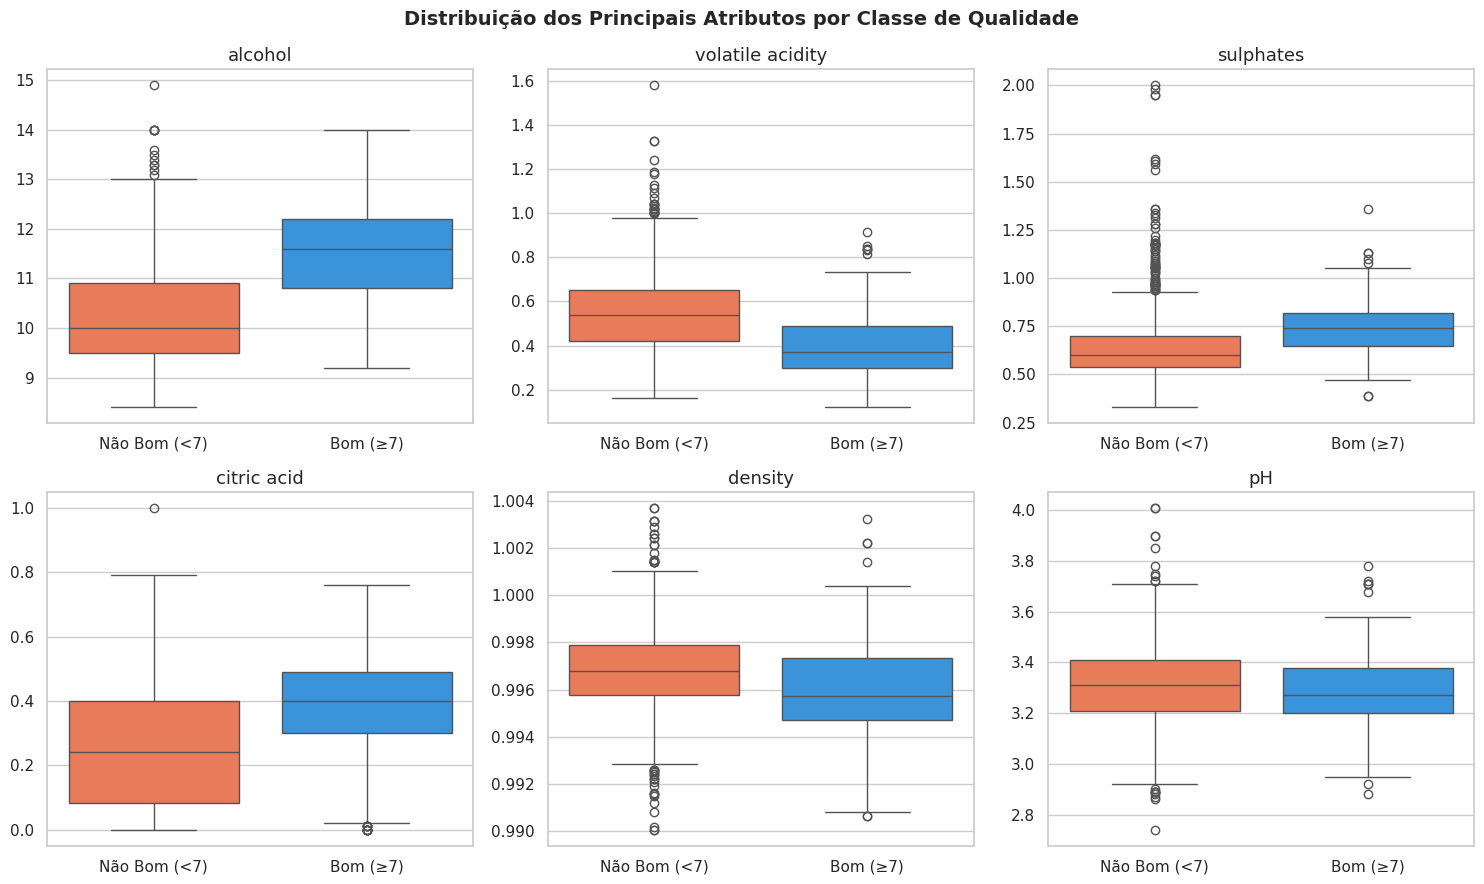

In [10]:
# Criar DataFrame temporário de cópia para esta visualização
# (sem alterar o DataFrame original df)
df_viz = df.copy()
df_viz['Classe'] = df_viz['quality'].apply(
    lambda x: 'Bom (≥7)' if x >= 7 else 'Não Bom (<7)'
)

# Atributos selecionados com base nas maiores correlações com quality
atributos_chave = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'pH']

palette = {'Bom (≥7)': '#2196F3', 'Não Bom (<7)': '#FF7043'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, atributo in enumerate(atributos_chave):
    sns.boxplot(
        data=df_viz,
        x='Classe',
        y=atributo,
        hue='Classe',        # Requerido para uso de palette em versões recentes do seaborn
        ax=axes[i],
        palette=palette,
        order=['Não Bom (<7)', 'Bom (≥7)'],  # Ordenar classes para leitura consistente
        legend=False          # Suprimir legenda automática (redundante com o eixo x)
    )
    axes[i].set_title(atributo)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Distribuição dos Principais Atributos por Classe de Qualidade',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise:**  
Os boxplots por classe confirmam visualmente as correlações identificadas no mapa de calor:

- **`alcohol`**: Mediana dos vinhos bons claramente superior (~11,5% vs ~10%). Separação entre classes evidente. **H1 confirmada.**
- **`volatile acidity`**: Vinhos bons têm mediana significativamente menor (~0,38 vs ~0,54 g/dm³). Bom poder discriminativo. **H2 confirmada.**
- **`sulphates`**: Vinhos bons tendem a ter concentração levemente maior. **H3 confirmada.**
- **`citric acid`**: Leve tendência a valores maiores em vinhos bons, mas com ampla sobreposição entre classes. **H4 parcialmente confirmada.**
- **`density`**: Vinhos bons têm menor densidade — esperado, dado o maior teor alcoólico (álcool é menos denso que água).
- **`pH`**: Distribuições bastante sobrepostas — pouco poder discriminativo isoladamente.

Os atributos `alcohol`, `volatile acidity` e `sulphates` são os candidatos mais promissores como preditores na etapa de modelagem.

---
## 4. Pré-processamento de Dados

Com base nos achados da análise exploratória, serão realizadas as seguintes operações de pré-processamento, na ordem apresentada:

1. **Remoção de duplicatas** — 240 linhas identificadas
2. **Criação da variável alvo binária** (`quality_bin`)
3. **Tratamento de outliers** via método IQR
4. **Normalização** (Min-Max Scaling) → `df_normalized`
5. **Padronização** (Z-score) → `df_standardized`

> ⚠️ **Nota sobre vazamento de dados (*data leakage*):** Em produção, os parâmetros dos scalers (mínimo/máximo para Min-Max; média/desvio-padrão para Z-score) devem ser ajustados (`fit`) **somente no conjunto de treino** e depois aplicados (`transform`) ao conjunto de teste, para evitar que informações do teste contaminem o treino. Neste MVP, aplicamos as transformações ao dataset completo pois o objetivo é apenas a análise exploratória — a separação treino/teste ocorrerá na etapa de modelagem.

### 4.1 Remoção de Duplicatas

Removemos as linhas duplicadas identificadas na análise de integridade dos dados, garantindo que cada observação contribua de forma independente para as análises e futuros modelos.

In [11]:
n_antes = len(df)

# Remover linhas duplicadas, mantendo a primeira ocorrência de cada registro
df_clean = df.drop_duplicates().reset_index(drop=True).copy()

n_depois = len(df_clean)
n_removidas = n_antes - n_depois

print(f'Instâncias antes da remoção: {n_antes}')
print(f'Instâncias após a remoção:   {n_depois}')
print(f'Linhas removidas:            {n_removidas} ({n_removidas / n_antes * 100:.1f}%)')

Instâncias antes da remoção: 1599
Instâncias após a remoção:   1359
Linhas removidas:            240 (15.0%)


**Justificativa:** A remoção de 240 duplicatas (~15%) garante que o dataset final seja composto por observações independentes, reduzindo o risco de overfitting e viés nas estimativas estatísticas.

### 4.2 Criação da Variável Alvo Binária

Convertemos a nota original (`quality`) em uma variável binária para o problema de classificação: vinhos com `quality ≥ 7` são classificados como **bons** (1), e os demais como **não bons** (0).

In [12]:
# Criar variável alvo binária com base no limiar quality >= 7
# O limiar 7 foi escolhido pois notas 7 e 8 representam vinhos acima da média
# segundo a escala de avaliação dos especialistas
df_clean['quality_bin'] = (df_clean['quality'] >= 7).astype(int)

# Verificar a distribuição resultante das classes
class_counts = df_clean['quality_bin'].value_counts().sort_index()
class_pct = (class_counts / len(df_clean) * 100).round(1)

print('=== Distribuição da Variável quality_bin ===')
print(f'  Não Bom (0): {class_counts[0]} amostras ({class_pct[0]}%)')
print(f'  Bom     (1): {class_counts[1]} amostras ({class_pct[1]}%)')
print(f'\nRazão de desbalanceamento: {class_counts[0] / class_counts[1]:.1f}:1')

=== Distribuição da Variável quality_bin ===
  Não Bom (0): 1175 amostras (86.5%)
  Bom     (1): 184 amostras (13.5%)

Razão de desbalanceamento: 6.4:1


**Justificativa:** O limiar `quality ≥ 7` foi escolhido com base na distribuição original das notas e no conhecimento do domínio. O desbalanceamento resultante (~6:1) confirma que técnicas de balanceamento de classes serão necessárias na modelagem.

### 4.3 Tratamento de Outliers (Método IQR)

Utilizamos o **método do intervalo interquartil (IQR)** para remover outliers. Um valor é considerado outlier se:
- `valor < Q1 - 1,5 × IQR` (limite inferior), ou  
- `valor > Q3 + 1,5 × IQR` (limite superior)

O IQR é preferido ao z-score neste caso por ser mais robusto em distribuições assimétricas.

In [13]:
def remover_outliers_iqr(dataframe, atributos):
    """
    Remove outliers de um DataFrame usando o método IQR (Intervalo Interquartil).

    Para cada atributo informado, calcula os limites inferior e superior
    com base em Q1 - 1.5*IQR e Q3 + 1.5*IQR, respectivamente, e remove
    as linhas com valores fora desses limites.

    Parâmetros:
        dataframe (pd.DataFrame): DataFrame original.
        atributos (list): Lista de nomes de colunas a verificar.

    Retorna:
        tuple: (DataFrame filtrado, DataFrame com relatório de outliers por atributo)
    """
    df_resultado = dataframe.copy()
    relatorio = []

    for col in atributos:
        Q1 = df_resultado[col].quantile(0.25)
        Q3 = df_resultado[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Contar outliers antes de remover
        n_outliers = (
            (df_resultado[col] < limite_inferior) |
            (df_resultado[col] > limite_superior)
        ).sum()

        relatorio.append({
            'Atributo': col,
            'Outliers': n_outliers,
            'Limite Inferior': round(limite_inferior, 4),
            'Limite Superior': round(limite_superior, 4)
        })

        # Remover linhas com outliers neste atributo
        df_resultado = df_resultado[
            (df_resultado[col] >= limite_inferior) &
            (df_resultado[col] <= limite_superior)
        ]

    return df_resultado, pd.DataFrame(relatorio)


# Aplicar remoção apenas nos atributos de entrada (nunca na variável alvo)
colunas_entrada = [col for col in df_clean.columns if col not in ['quality', 'quality_bin']]

df_clean, relatorio_outliers = remover_outliers_iqr(df_clean, colunas_entrada)

print('=== Relatório de Outliers Removidos ===')
display(relatorio_outliers)
print(f'\nInstâncias restantes após remoção de outliers: {len(df_clean)}')

=== Relatório de Outliers Removidos ===


,Atributo,Outliers,Limite Inferior,Limite Superior
0,fixed acidity,41,3.9500,12.3500
1,volatile acidity,19,0.0150,1.0150
2,citric acid,1,-0.3975,0.9025
3,residual sugar,112,0.8500,3.6500
4,chlorides,73,0.0375,0.1215
5,free sulfur dioxide,23,-11.5000,40.5000
6,total sulfur dioxide,44,-33.5000,114.5000
7,density,20,0.9924,1.0006
8,pH,16,2.9600,3.6800
9,sulphates,23,0.3100,0.9500



Instâncias restantes após remoção de outliers: 985


**Justificativa:** A remoção por IQR garante que a distribuição dos dados seja mais representativa do comportamento típico dos vinhos. A escolha por **remoção** (em vez de substituição pela mediana) é adequada dado o volume do dataset; substituir por estatísticas de tendência central poderia mascarar a variabilidade real e criar padrões artificiais. Atributos como `residual sugar`, `chlorides` e `total sulfur dioxide` — com forte assimetria confirmada nas visualizações — são os que mais se beneficiam desse tratamento.

### 4.4 Normalização (Min-Max Scaling)

A normalização transforma cada atributo para o intervalo **[0, 1]**, preservando a forma da distribuição original. É especialmente útil para algoritmos baseados em distância (K-NN, SVM) e redes neurais, que são sensíveis à escala dos dados.

In [14]:
# Instanciar o scaler – parâmetros padrão: feature_range=(0, 1)
scaler_minmax = MinMaxScaler()

# Criar cópia para preservar o dataset original sem transformação
df_normalized = df_clean.copy()

# Aplicar normalização somente nos atributos de entrada
# Nota: em produção, o fit() deve ser feito somente no conjunto de treino
df_normalized[colunas_entrada] = scaler_minmax.fit_transform(df_clean[colunas_entrada])

print('=== Dataset Normalizado (Min-Max [0,1]) – Estatísticas dos Atributos de Entrada ===')
display(df_normalized[colunas_entrada].describe().round(4))

=== Dataset Normalizado (Min-Max [0,1]) – Estatísticas dos Atributos de Entrada ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000
mean,0.4220,0.4525,0.3397,0.4036,0.4835,0.3518,0.3257,0.5134,0.4923,0.4899,0.3607
std,0.2029,0.1890,0.2495,0.1831,0.1803,0.2199,0.2333,0.1978,0.1874,0.1830,0.2108
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.2778,0.3034,0.1096,0.2857,0.3614,0.1795,0.1481,0.3875,0.3571,0.3607,0.1702
50%,0.3750,0.4494,0.3288,0.3673,0.4819,0.3077,0.2685,0.5125,0.4857,0.4590,0.2979
75%,0.5417,0.5787,0.5479,0.5306,0.5904,0.4872,0.4537,0.6350,0.6143,0.6066,0.5106
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


**Justificativa:** O `MinMaxScaler` é indicado quando queremos que todos os atributos contribuam igualmente para métricas de distância, sem assumir distribuição normal dos dados. Após a normalização, todos os atributos têm mínimo ≈ 0 e máximo ≈ 1, conforme esperado. As variáveis alvo (`quality` e `quality_bin`) **não foram normalizadas**, pois são rótulos discretos e não devem ser tratados como atributos contínuos.

### 4.5 Padronização (Z-score / Standard Scaling)

A padronização transforma os atributos para que tenham **média 0** e **desvio-padrão 1**. É adequada para algoritmos que assumem distribuição aproximadamente normal, como Regressão Logística, Análise Discriminante Linear e algoritmos baseados em gradiente.

In [15]:
# Instanciar o scaler de padronização
scaler_std = StandardScaler()

# Criar cópia para preservar o dataset normalizado intacto
df_standardized = df_clean.copy()

# Aplicar padronização somente nos atributos de entrada
# Nota: em produção, o fit() deve ser feito somente no conjunto de treino
df_standardized[colunas_entrada] = scaler_std.fit_transform(df_clean[colunas_entrada])

print('=== Dataset Padronizado (Z-score) – Estatísticas dos Atributos de Entrada ===')
display(df_standardized[colunas_entrada].describe().round(4))

=== Dataset Padronizado (Z-score) – Estatísticas dos Atributos de Entrada ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000,985.0000
mean,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005
min,-2.0813,-2.3956,-1.3623,-2.2060,-2.6827,-1.6009,-1.3965,-2.5965,-2.6285,-2.6778,-1.7124
25%,-0.7114,-0.7894,-0.9227,-0.6445,-0.6771,-0.7841,-0.7613,-0.6367,-0.7215,-0.7065,-0.9044
50%,-0.2319,-0.0160,-0.0437,-0.1984,-0.0086,-0.2007,-0.2452,-0.0045,-0.0349,-0.1689,-0.2983
75%,0.5900,0.6681,0.8354,0.6939,0.5931,0.6161,0.5488,0.6151,0.6516,0.6375,0.7117
max,2.8504,2.8989,2.6485,3.2592,2.8660,2.9498,2.8911,2.4612,2.7113,2.7880,3.0347


**Justificativa:** Após a padronização, cada atributo tem média ≈ 0 e desvio-padrão ≈ 1, conforme esperado. A padronização é mais robusta do que a normalização quando há outliers residuais, pois não comprime toda a distribuição para um intervalo fixo. Disponibilizamos tanto a versão normalizada (`df_normalized`) quanto a padronizada (`df_standardized`) para que diferentes algoritmos possam ser avaliados na etapa de modelagem.

### 4.6 Síntese das Versões do Dataset

Ao final do pré-processamento, temos três versões do dataset prontas para a etapa de modelagem, cada uma adequada a diferentes algoritmos.

In [16]:
# Resumo final das versões geradas
print('=== Versões do Dataset Após Pré-processamento ===')
print(f'  df_clean        (escala original, sem outliers):  {df_clean.shape}')
print(f'  df_normalized   (Min-Max [0,1]):                  {df_normalized.shape}')
print(f'  df_standardized (Z-score, média=0, dp=1):         {df_standardized.shape}')

print(f'\nAtributos de entrada: {len(colunas_entrada)}')
print(f'Variável alvo original:   quality       (discreta, escala 0–10)')
print(f'Variável alvo binária:    quality_bin   (0 = não bom, 1 = bom [quality ≥ 7])')

# Distribuição final das classes após todo o pré-processamento
class_final = df_clean['quality_bin'].value_counts().sort_index()
print(f'\nDistribuição das classes (df_clean):')
print(f'  Não Bom (0): {class_final[0]} ({class_final[0] / len(df_clean) * 100:.1f}%)')
print(f'  Bom     (1): {class_final[1]} ({class_final[1] / len(df_clean) * 100:.1f}%)')

=== Versões do Dataset Após Pré-processamento ===
  df_clean        (escala original, sem outliers):  (985, 13)
  df_normalized   (Min-Max [0,1]):                  (985, 13)
  df_standardized (Z-score, média=0, dp=1):         (985, 13)

Atributos de entrada: 11
Variável alvo original:   quality       (discreta, escala 0–10)
Variável alvo binária:    quality_bin   (0 = não bom, 1 = bom [quality ≥ 7])

Distribuição das classes (df_clean):
  Não Bom (0): 860 (87.3%)
  Bom     (1): 125 (12.7%)


---
## 5. Análise Exploratória Pós-processamento

Após o pré-processamento, revisitamos as distribuições dos dados para verificar o impacto das operações realizadas e identificar novos insights que possam surgir com os dados limpos.

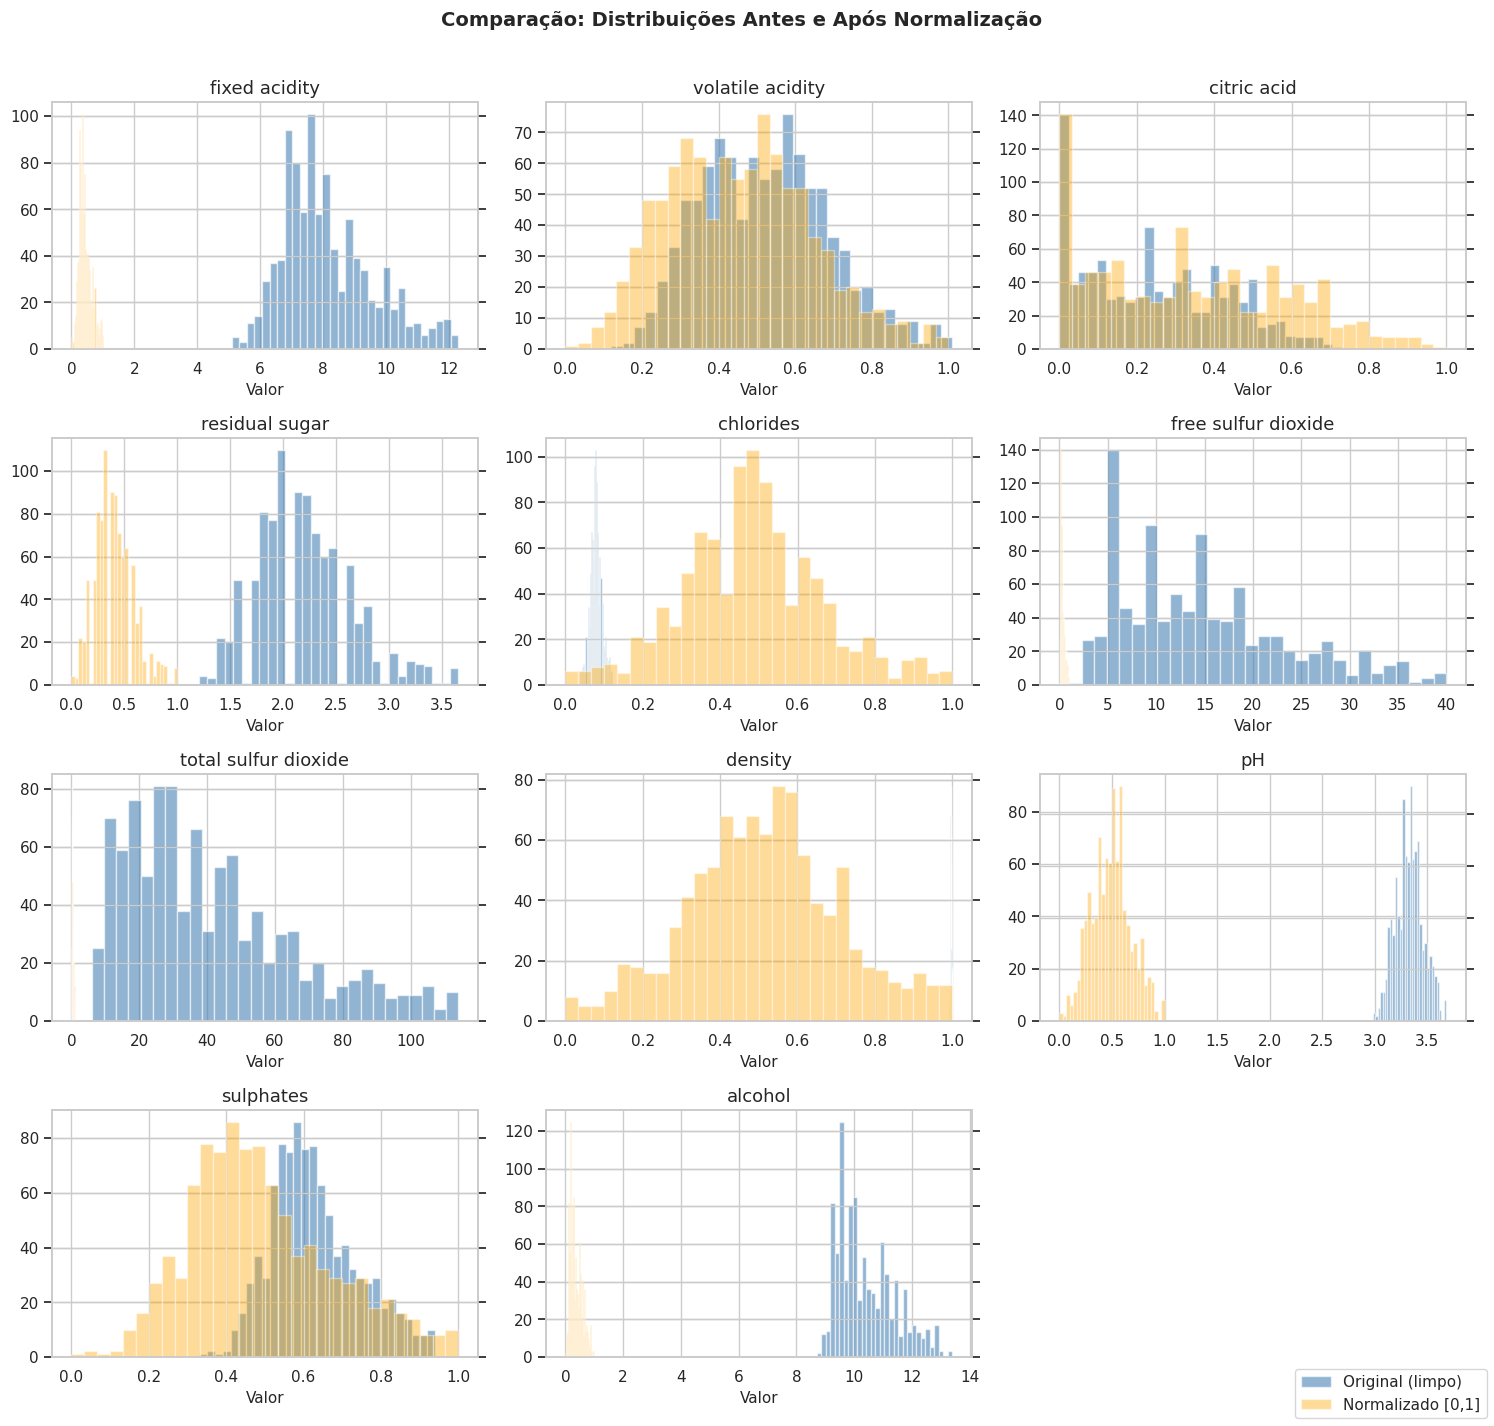

In [17]:
# Comparação das distribuições antes (escala original, pós-limpeza) e após normalização
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(colunas_entrada):
    # Histograma do dataset limpo (escala original)
    axes[i].hist(
        df_clean[col], bins=30, alpha=0.6,
        label='Original (limpo)', color='steelblue', edgecolor='white'
    )

    # Eixo secundário para o dataset normalizado (escalas diferentes)
    ax2 = axes[i].twinx()
    ax2.hist(
        df_normalized[col], bins=30, alpha=0.4,
        label='Normalizado [0,1]', color='orange', edgecolor='white'
    )
    ax2.set_yticklabels([])  # Esconder eixo Y secundário para não sobrecarregar a visualização

    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')

# Esconder subplots extras (11 atributos, 12 subplots)
for j in range(len(colunas_entrada), len(axes)):
    axes[j].set_visible(False)

# Legenda global para identificar as duas séries
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.6, label='Original (limpo)'),
    Patch(facecolor='orange', alpha=0.4, label='Normalizado [0,1]')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.suptitle('Comparação: Distribuições Antes e Após Normalização',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Análise:**  
A comparação pós-processamento confirma os efeitos esperados de cada operação:

- **Impacto da remoção de outliers:** As distribuições de `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide` estão visivelmente mais simétricas e compactas em comparação com os histogramas originais, confirmando que os outliers extremos foram eliminados com sucesso.
- **Impacto da normalização:** A sobreposição dos histogramas (azul e laranja) confirma que a normalização **preserva a forma** das distribuições — apenas reescala os valores para [0, 1]. Atributos com distribuições assimétricas permanecem assimétricos após a normalização.
- **`citric acid`:** Mantém a característica bimodal mesmo após a limpeza, o que pode ser explorado com técnicas de discretização em etapas futuras.

O dataset está agora limpo, consistente e disponível em três versões para a futura etapa de modelagem.

---
## 6. Conclusão

### Resumo das Etapas Realizadas

| Etapa | Resultado |
|---|---|
| **Definição do problema** | Classificação binária: prever se um vinho tinto é *bom* (quality ≥ 7) ou *não bom* |
| **Dataset** | 1.599 instâncias · 12 atributos · sem valores faltantes |
| **Remoção de duplicatas** | 240 linhas removidas → 1.359 instâncias |
| **Análise estatística** | Assimetrias identificadas em `residual sugar`, `chlorides`, `free SO₂` e `total SO₂` |
| **Correlações** | `alcohol`, `volatile acidity` e `sulphates` são os atributos mais correlacionados com qualidade |
| **Variável alvo binária** | `quality_bin` criada; desbalanceamento ~6:1 identificado |
| **Outliers** | Removidos via IQR em todos os atributos de entrada |
| **Normalização** | MinMaxScaler → `df_normalized` (valores em [0, 1]) |
| **Padronização** | StandardScaler → `df_standardized` (média = 0, dp = 1) |

### Hipóteses Validadas

| Hipótese | Status | Evidência |
|---|---|---|
| H1 – Álcool → qualidade | ✅ Confirmada | r = +0,48; boxplots por classe |
| H2 – Acidez volátil → qualidade inversa | ✅ Confirmada | r = -0,39; boxplots por classe |
| H3 – Sulfatos → qualidade | ✅ Confirmada | r = +0,25 |
| H4 – Ácido cítrico → qualidade | ⚠️ Parcial | r = +0,23; ampla sobreposição entre classes |

### Próximos Passos (Etapa de Modelagem)

1. **Balanceamento de classes:** Aplicar SMOTE ou `class_weight='balanced'` nos classificadores.
2. **Feature selection:** Avaliar remoção de atributos com alta multicolinearidade (`fixed acidity` × `density`; `free SO₂` × `total SO₂`).
3. **Modelagem:** Treinar e comparar classificadores como Árvore de Decisão, Random Forest e Regressão Logística com as três versões do dataset.
4. **Avaliação:** Usar F1-score e AUC-ROC como métricas principais, dado o desbalanceamento de classes.
5. **Separação treino/teste:** Aplicar os scalers corretamente (fit somente no treino) para evitar vazamento de dados.